#按照論文中敘述的CNN-LSTM模型
#研究主題：
##建立一個基於 CNN 與 LSTM 的深度學習混合模型，用於 網路入侵偵測系統（Intrusion Detection System, IDS）。

#研究動機與背景：
##傳統 IDS 主要使用簽章（Signature-Based）或簡單機器學習。

##對新型攻擊、零日攻擊（Zero-Day Attacks）無法準確偵測。

##深度學習可自動提取特徵，具備時序記憶與空間辨識能力。

##CNN 擅長抽取空間特徵；LSTM 擅長分析時間序列。

#模型架構：CNN-LSTM Hybrid:
##CNN 區塊：

##多個卷積層 (Conv1D) + 池化層 (MaxPooling1D)。

##每層加上 BatchNormalization 與 Dropout，減少過擬合與協變偏移。

##LSTM 區塊：

##使用 LSTM 層學習時間序列資料的長期依賴性。

##分類器：

##若為二分類，最後使用 Dense(1, activation='sigmoid')。

##若為多分類，使用 Dense(n_classes, activation='softmax')。

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import seaborn as sns


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, MaxPooling1D, Flatten
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Step 1：資料載入與預處理

In [29]:
df_syn = pd.read_csv("syn_flood.csv")
df_rst = pd.read_csv("rst_flood.csv")
df_fin = pd.read_csv("fin_flood.csv")
df_ack=pd.read_csv("ack_flood.csv")
df = pd.concat([df_syn, df_rst,df_fin,df_ack], ignore_index=True)
#df = pd.read_csv("data_change.csv", parse_dates=["bidirectional_first_seen_ms","bidirectional_last_seen_ms","src2dst_first_seen_ms","src2dst_last_seen_ms","dst2src_first_seen_ms","dst2src_last_seen_ms"])

C:\Users\User\AppData\Local\Temp\ipykernel_30784\2368268077.py:3: DtypeWarning: Columns (84,85) have mixed types. Specify dtype option on import or set low_memory=False.
  df_fin = pd.read_csv("fin_flood.csv")


In [30]:
#df[['Source', 'Destination', *_]] = df['Flow ID'].str.split('-', expand=True)
df = df.sort_values("bidirectional_first_seen_ms")

In [31]:
df = df.drop(columns=["id",
                       "src_ip", 
                       "src_mac", 
                       "src_oui", 
                       "src_port", 
                       "dst_ip", 
                       "dst_mac",
                       "dst_oui",
                       "dst_port",
                       "ip_version",
                       "vlan_id",
                       "tunnel_id",
                       "bidirectional_first_seen_ms",
                       "bidirectional_last_seen_ms",
                       "src2dst_first_seen_ms",
                        "src2dst_last_seen_ms",
                        "dst2src_first_seen_ms",
                        "dst2src_last_seen_ms",
                        "application_name",
                        "application_category_name",
                        "application_is_guessed",
                        "requested_server_name",
                        "client_fingerprint",
                        "server_fingerprint",
                        "user_agent",
                        "content_type",

                        "bidirectional_min_ps",
                        "bidirectional_mean_ps",
                        "bidirectional_stddev_ps",
                        "bidirectional_max_ps",
                        "src2dst_min_ps",
                        "src2dst_mean_ps",
                        "src2dst_stddev_ps",
                        "src2dst_max_ps",
                        "dst2src_min_ps",
                        "dst2src_mean_ps",
                        "dst2src_stddev_ps",
                        "dst2src_max_ps",
                        
                       ], errors='ignore')



In [32]:
print(f"欄位數量: {len(df.columns)}")
print(df.columns.tolist())

欄位數量: 49
['expiration_id', 'protocol', 'bidirectional_duration_ms', 'bidirectional_packets', 'bidirectional_bytes', 'src2dst_duration_ms', 'src2dst_packets', 'src2dst_bytes', 'dst2src_duration_ms', 'dst2src_packets', 'dst2src_bytes', 'bidirectional_min_piat_ms', 'bidirectional_mean_piat_ms', 'bidirectional_stddev_piat_ms', 'bidirectional_max_piat_ms', 'src2dst_min_piat_ms', 'src2dst_mean_piat_ms', 'src2dst_stddev_piat_ms', 'src2dst_max_piat_ms', 'dst2src_min_piat_ms', 'dst2src_mean_piat_ms', 'dst2src_stddev_piat_ms', 'dst2src_max_piat_ms', 'bidirectional_syn_packets', 'bidirectional_cwr_packets', 'bidirectional_ece_packets', 'bidirectional_urg_packets', 'bidirectional_ack_packets', 'bidirectional_psh_packets', 'bidirectional_rst_packets', 'bidirectional_fin_packets', 'src2dst_syn_packets', 'src2dst_cwr_packets', 'src2dst_ece_packets', 'src2dst_urg_packets', 'src2dst_ack_packets', 'src2dst_psh_packets', 'src2dst_rst_packets', 'src2dst_fin_packets', 'dst2src_syn_packets', 'dst2src_cwr_pa

In [33]:
# Label encoding
le = LabelEncoder()
df['Label_encoded'] = le.fit_transform(df['Label'])

X = df.drop(columns=["Label", "Label_encoded"])
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
y = df['Label_encoded'].values

In [34]:
print(le.classes_)  # 這會是字母順序，這是 LabelEncoder 的預設行為

['ack_flood' 'fin_flood' 'normal' 'rst_flood' 'syn_flood']


# === 2. 標準化與序列化（以時間為序列）===

In [35]:
scaler = StandardScaler()
# 特徵數可以試 50（論文提到是最佳）
k_best = SelectKBest(score_func=f_classif, k=40)
X_selected = k_best.fit_transform(X, y)
X_scaled = scaler.fit_transform(X_selected)

def create_sequences(X, y, window_size=10):
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i:i+window_size])
        y_seq.append(y[i+window_size])  # 預測最後一筆
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y, window_size=10)

# 分割訓練與測試
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.3, random_state=42, stratify=y_seq
)

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [24 25 26 32 33 34 40 41 42] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [36]:
import joblib
joblib.dump(k_best, 'kbest.save')
joblib.dump(scaler, 'scaler.save')
joblib.dump(le, 'label_encoder.save')

['label_encoder.save']

# === 3. CNN-LSTM 模型建立 ===

In [37]:
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(MaxPooling1D(pool_size=2))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(LSTM(64, return_sequences=True))  # 第一層 LSTM return_sequences=True 才能接第二層
model.add(Dropout(0.2))

# 第二層
model.add(Conv1D(filters=32, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(LSTM(32))  # 最後一層 LSTM 不需 return_sequences

# 最終分類層
model.add(Dense(32, activation='relu'))
model.add(Dense(5, activation='softmax'))  # 4類
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# model.add(Dense(1, activation='sigmoid'))  # 二分類

# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# === 4. 訓練 ===

In [38]:
model.fit(X_train, y_train, epochs=10, batch_size=128, validation_split=0.1,
          callbacks=[EarlyStopping(monitor='val_loss', patience=2)], verbose=1)

Epoch 1/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8911 - loss: 0.5082 - val_accuracy: 0.9679 - val_loss: 0.1084
Epoch 2/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9667 - loss: 0.1124 - val_accuracy: 0.9692 - val_loss: 0.1020
Epoch 3/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9684 - loss: 0.1037 - val_accuracy: 0.9692 - val_loss: 0.0999
Epoch 4/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9672 - loss: 0.1054 - val_accuracy: 0.9686 - val_loss: 0.1021
Epoch 5/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9684 - loss: 0.1014 - val_accuracy: 0.9693 - val_loss: 0.0986
Epoch 6/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9697 - loss: 0.1002 - val_accuracy: 0.9695 - val_loss: 0.0994
Epoch 7/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9700 - loss: 0.0970 - val_accuracy: 0.9691 - val_loss: 0.0983
Epoch 8/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9693 - loss: 0.0973 - val_accuracy: 0.

In [39]:
model.save('cnn_lstm_model.h5')

# === 5. 評估 ===

In [40]:
print(le.classes_)  # 例如: ['normal', 'rst_flood', 'syn_flood']

['ack_flood' 'fin_flood' 'normal' 'rst_flood' 'syn_flood']


In [41]:
print(np.unique(y_test, return_counts=True))
print(le.inverse_transform(np.unique(y_test)))

(array([0, 1, 2, 3, 4]), array([ 2479,  1843, 22416,  1318,  1577], dtype=int64))
['ack_flood' 'fin_flood' 'normal' 'rst_flood' 'syn_flood']


927/927 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

=== Classification Report (CNN-LSTM) ===
              precision    recall  f1-score   support

   ack_flood       0.90      0.98      0.94      2479
   fin_flood       0.93      0.97      0.95      1843
      normal       0.99      0.96      0.98     22416
   rst_flood       0.89      0.99      0.94      1318
   syn_flood       0.87      0.98      0.92      1577

    accuracy                           0.97     29633
   macro avg       0.92      0.98      0.95     29633
weighted avg       0.97      0.97      0.97     29633



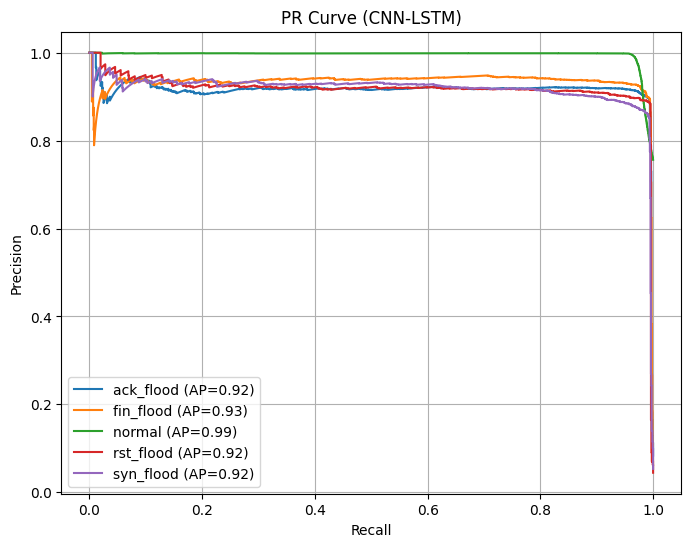

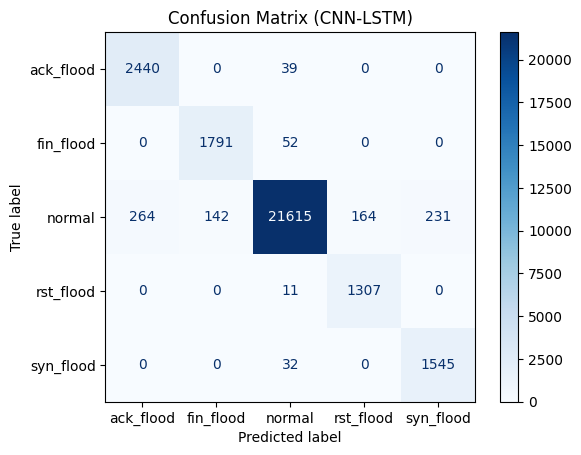

In [42]:
# y_prob = model.predict(X_test).ravel()
# y_pred = (y_prob > 0.5).astype(int)
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)
print("\n=== Classification Report (CNN-LSTM) ===")
print(classification_report(
    y_test, y_pred,
    labels=[0, 1, 2, 3,4],  # 依照 le.classes_ 的順序
    target_names=le.classes_
))

from sklearn.preprocessing import label_binarize

# 將 y_test 轉為 one-hot
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3,4])

plt.figure(figsize=(8,6))
for i, class_name in enumerate(le.classes_):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_prob[:, i])
    plt.plot(recall, precision, label=f'{class_name} (AP={ap:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve (CNN-LSTM)")
plt.grid()
plt.legend()
plt.show()


#confusion matrix
labels = [0, 1, 2,3,4]  # 依照 le.classes_ 的順序
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (CNN-LSTM)")
plt.show()